# 02 — Preprocessing

Limpieza de minutas, parsing de fechas, construcción de etiquetas (`hike` / `cut` / `hold`) a partir de la variación de la federal funds target rate (FRED).

**Inputs:**
- `data/raw/minutes/` — 884 archivos .txt (usamos sólo 2000–2023: 193 docs)
- FRED API — series `DFEDTAR` (pre-2008) y `DFEDTARU` (post-2008)

**Output:** `data/processed/fomc_dataset.csv` — columnas `[date, text, label, split]`

In [1]:
import pandas as pd
import numpy as np
import html as html_lib
import string
import requests
from io import StringIO
from pathlib import Path

import nltk

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Rutas
BASE_DIR       = Path('..').resolve()
DATA_RAW       = BASE_DIR / 'data' / 'raw'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
MINUTES_DIR    = DATA_RAW / 'minutes'
RATES_DIR      = DATA_RAW / 'rates'

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
RATES_DIR.mkdir(parents=True, exist_ok=True)

n_minutes = len(list(MINUTES_DIR.glob('*.txt')))
print(f'Entorno configurado. Minutas en disco: {n_minutes}')

Entorno configurado. Minutas en disco: 884


## 1. Descarga de tasas FRED

La Fed publica la federal funds target rate en FRED:
- **DFEDTAR** (2000–2008): tasa única (régimen pre-2008).
- **DFEDTARU** (2008–2023): cota superior del rango (régimen post-2008); usamos la cota superior como proxy del target.

Descargamos directamente el CSV público de FRED via `requests` (sin `pandas_datareader`, incompatible con Python 3.14). Los labels emergen del diff entre fechas de minutas consecutivas.

Serie diaria: 2000-01-01 -> 2023-12-31
Rango de tasas: 0.25% - 6.50%


<Axes: title={'center': 'Federal Funds Target Rate (FRED)'}, xlabel='observation_date', ylabel='% anual'>

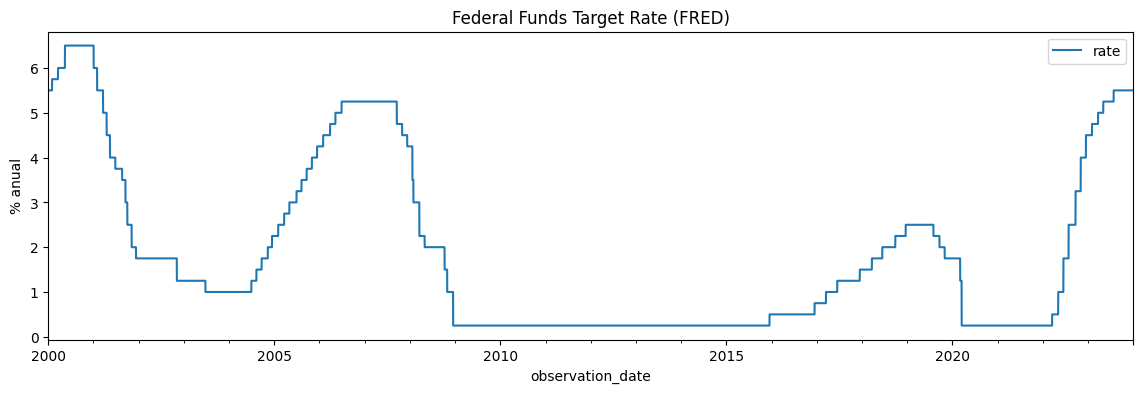

In [2]:
def download_fred(series_id):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text), na_values=['.'])
    # FRED CSV usa 'observation_date' como nombre de columna
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    df.columns = ['rate']
    df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
    return df.dropna()

# Pre-2008: tasa única
dfedtar  = download_fred('DFEDTAR')['2000-01-01':'2008-12-31']

# Post-2008: cota superior del rango
dfedtaru = download_fred('DFEDTARU')['2008-12-01':'2023-12-31']

# Concatenar, eliminar solapamiento, remuestrear a diario con forward fill
raw_series  = pd.concat([dfedtar, dfedtaru]).sort_index()
raw_series  = raw_series[~raw_series.index.duplicated(keep='last')]
target_rate = raw_series.resample('D').last().ffill()

# Guardar para reproducibilidad
target_rate.to_csv(RATES_DIR / 'fred_target_rate.csv')

start = target_rate.index[0].date()
end   = target_rate.index[-1].date()
rmin  = target_rate['rate'].min()
rmax  = target_rate['rate'].max()
print(f'Serie diaria: {start} -> {end}')
print(f'Rango de tasas: {rmin:.2f}% - {rmax:.2f}%')

target_rate.plot(figsize=(14, 4), title='Federal Funds Target Rate (FRED)', ylabel='% anual')

## 2. Carga de minutas

Cargamos los 193 documentos en el rango 2000–2023. El nombre del archivo codifica la fecha de la **reunión** (no la fecha de publicación, que es ~3 semanas después). Los archivos fuera de rango se descartan.

In [3]:
records = []
for path in sorted(MINUTES_DIR.glob('*.txt')):
    date_str = path.stem.replace('_minutes', '')
    try:
        date = pd.to_datetime(date_str)
    except Exception:
        continue
    if date.year < 2000 or date.year > 2023:
        continue
    text = path.read_text(encoding='utf-8', errors='replace')
    records.append({'date': date, 'text': text})

df = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
print(f'Minutas cargadas: {len(df)}')
print(f"Rango: {df['date'].min().date()} -> {df['date'].max().date()}")
df[['date']].head()

Minutas cargadas: 193
Rango: 2000-02-02 -> 2023-12-13


,date
0,2000-02-02
1,2000-03-21
2,2000-05-16
3,2000-06-28
4,2000-08-22


## 3. Construcción de etiquetas

Para cada minuta M (orden cronológico) comparamos la tasa vigente en la fecha de M con la tasa vigente en la fecha de M-1:
- **hike**: `rate_M > rate_{M-1}`
- **cut**: `rate_M < rate_{M-1}`
- **hold**: `rate_M == rate_{M-1}`

La primera minuta no tiene referencia previa → se le asigna `hold` por convención. El `asof()` garantiza un valor válido aunque la reunión caiga en fin de semana o feriado.

In [4]:
rate_series = target_rate['rate']

# Tasa vigente en cada fecha de reunión
df['rate'] = df['date'].apply(lambda d: rate_series.asof(d))

# Diferencia con la reunión anterior
df['rate_prev'] = df['rate'].shift(1)
df['delta']     = df['rate'] - df['rate_prev']

def assign_label(row):
    if pd.isna(row['rate_prev']):
        return 'hold'
    if row['delta'] > 0:
        return 'hike'
    if row['delta'] < 0:
        return 'cut'
    return 'hold'

df['label'] = df.apply(assign_label, axis=1)

print('Distribucion de etiquetas:')
print(df['label'].value_counts())

Distribucion de etiquetas:
label
hold    131
hike     39
cut      23
Name: count, dtype: int64


In [5]:
# Sanity check: verificar contra eventos historicos conocidos
check = df[['date', 'rate_prev', 'rate', 'delta', 'label']].copy()

print('--- Recortes 2007-2009 (esperado: varios cut) ---')
mask = (check['date'] >= '2007-09-01') & (check['date'] <= '2009-07-01')
print(check[mask][['date', 'rate_prev', 'rate', 'delta', 'label']].to_string(index=False))

print()
print('--- Alzas 2022-2023 (esperado: varios hike) ---')
mask2 = check['date'] >= '2022-01-01'
print(check[mask2][['date', 'rate_prev', 'rate', 'delta', 'label']].to_string(index=False))

--- Recortes 2007-2009 (esperado: varios cut) ---
      date  rate_prev  rate  delta label
2007-09-18       5.25  4.75  -0.50   cut
2007-10-31       4.75  4.50  -0.25   cut
2007-12-11       4.50  4.25  -0.25   cut
2008-01-30       4.25  3.00  -1.25   cut
2008-03-18       3.00  2.25  -0.75   cut
2008-04-30       2.25  2.00  -0.25   cut
2008-06-25       2.00  2.00   0.00  hold
2008-08-05       2.00  2.00   0.00  hold
2008-09-16       2.00  2.00   0.00  hold
2008-10-29       2.00  1.00  -1.00   cut
2008-12-16       1.00  0.25  -0.75   cut
2009-01-28       0.25  0.25   0.00  hold
2009-03-18       0.25  0.25   0.00  hold
2009-04-29       0.25  0.25   0.00  hold
2009-06-24       0.25  0.25   0.00  hold

--- Alzas 2022-2023 (esperado: varios hike) ---
      date  rate_prev  rate  delta label
2022-01-26       0.25  0.25   0.00  hold
2022-03-16       0.25  0.25   0.00  hold
2022-05-04       0.25  0.50   0.25  hike
2022-06-15       0.50  1.00   0.50  hike
2022-07-27       1.00  1.75   0.75  hike

## 4. Limpieza de texto

Pipeline estándar de preprocesamiento sobre el texto crudo de cada minuta:
1. Desescapar HTML (`html.unescape`)
2. Minúsculas
3. Eliminar puntuación y dígitos (via `str.translate`, sin regex)
4. Tokenizar con `nltk.word_tokenize`
5. Eliminar stopwords inglés + términos de dominio (`committee`, `meeting`, `board`, `federal`, `reserve`)
6. Filtrar tokens de longitud ≤ 2

In [6]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

DOMAIN_SW    = {'committee', 'meeting', 'board', 'federal', 'reserve'}
SW_EN        = set(stopwords.words('english')) | DOMAIN_SW
REMOVE_CHARS = string.punctuation + string.digits

def preprocess_text(text: str) -> str:
    text = html_lib.unescape(text)
    text = text.lower()
    text = text.translate(str.maketrans('', '', REMOVE_CHARS))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in SW_EN and len(t) > 2]
    return ' '.join(tokens)

# Prueba rapida
raw_sample   = df.loc[0, 'text'][:500]
clean_sample = preprocess_text(raw_sample)
print('Original (500 chars):')
print(raw_sample[:200])
print()
print('Procesado:')
print(clean_sample[:200])

Original (500 chars):
FRB: FOMC Minutes - February 1-2, 2000


Minutes of the Federal Open Market Committee


February 1-2, 2000


A meeting of the Federal Open Market Committee was held in the offices of the Board of Gove

Procesado:
frb fomc minutes february minutes open market february open market held offices governors system washington tuesday february continued wednesday february present greenspan chairman mcdonough vice chai


In [7]:
from tqdm.auto import tqdm
tqdm.pandas(desc='Preprocesando')

df['text'] = df['text'].progress_apply(preprocess_text)

mean_len = df['text'].str.split().str.len().mean()
print(f'Longitud media post-limpieza: {mean_len:.0f} tokens')
sample = df.loc[0, 'text'][:300]
print(f'Ejemplo:\n{sample}')

Preprocesando:   0%|          | 0/193 [00:00<?, ?it/s]

Longitud media post-limpieza: 4277 tokens
Ejemplo:
frb fomc minutes february minutes open market february open market held offices governors system washington tuesday february continued wednesday february present greenspan chairman mcdonough vice chairman broaddus ferguson gramlich guynn jordan kelley meyer parry hoenig minehan messrs moskow poole a


## 5. Split cronológico

Split fijo según año de la reunión — **no aleatorio**. El split cronológico evita data leakage temporal: las minutas post-2005 tienen un estilo lingüístico diferente (FOMC comenzó a publicar más detalle de debate), y un split aleatorio mezclaría regímenes inflando artificialmente las métricas.

| Split | Años     | Docs esperados |
|-------|----------|----------------|
| train | 2000–2018 | 153            |
| val   | 2019–2020 | 16             |
| test  | 2021–2023 | 24             |

In [8]:
def assign_split(date):
    if date.year <= 2018:
        return 'train'
    if date.year <= 2020:
        return 'val'
    return 'test'

df['split'] = df['date'].apply(assign_split)

print('Distribucion por split y etiqueta:')
tabla = df.groupby(['split', 'label']).size().unstack(fill_value=0)
print(tabla)
print()
print('Conteo por split:')
print(df['split'].value_counts())
print(f'Total: {len(df)} documentos')

Distribucion por split y etiqueta:
label  cut  hike  hold
split                 
test     0    11    13
train   18    27   108
val      5     1    10

Conteo por split:
split
train    153
test      24
val       16
Name: count, dtype: int64
Total: 193 documentos


## 6. Guardado del dataset

Guardamos el dataset final con columnas `[date, text, label, split]`. El texto almacenado es el texto **preprocesado**. Los notebooks de modelado (`04_tfidf.ipynb`, `05_lm_lexicon.ipynb`, etc.) cargan directamente este CSV.

In [9]:
out_cols = ['date', 'text', 'label', 'split']
out_path = DATA_PROCESSED / 'fomc_dataset.csv'
df[out_cols].to_csv(out_path, index=False)

print(f'Dataset guardado: {out_path}')
print(f'Shape: {df[out_cols].shape}')
df[out_cols].head(3)

Dataset guardado: /Users/valentinruiz/Documents/ITBA_(yo)/3ero/2do_cuatri/NLP/TP_NLP/data/processed/fomc_dataset.csv
Shape: (193, 4)


,date,text,label,split
0,2000-02-02,frb fomc minutes february minutes open market ...,hold,train
1,2000-03-21,frb fomc minutes march minutes open market mar...,hike,train
2,2000-05-16,frb fomc minutes may minutes open market may o...,hike,train
